In [22]:
from google.colab import files
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, accuracy_score
from sklearn.model_selection import TimeSeriesSplit
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import f1_score
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.metrics import classification_report, confusion_matrix


In [2]:

uploaded = files.upload()


for fn in uploaded.keys():
  print(f'User uploaded file "{fn}"')
  df = pd.read_csv(fn)



Saving reservations_train.csv to reservations_train.csv
User uploaded file "reservations_train.csv"


# 1) Exploratory data analysis et preparation

In [3]:
# Afficher les informations du DataFrame
display(df.shape)
display(df.info())
display(df.head())


(8000, 34)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8000 entries, 0 to 7999
Data columns (total 34 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   reservation_id             8000 non-null   object 
 1   date_reservation           8000 non-null   object 
 2   date_arrivee               8000 non-null   object 
 3   region_hotel               8000 non-null   object 
 4   ville                      8000 non-null   object 
 5   type_destination           8000 non-null   object 
 6   hotel_id                   8000 non-null   object 
 7   categorie_hotel            8000 non-null   int64  
 8   segment_client             8000 non-null   object 
 9   marche_origine             7809 non-null   object 
 10  canal_reservation          8000 non-null   object 
 11  moyen_transport            8000 non-null   object 
 12  delai_reservation_jours    8000 non-null   int64  
 13  nuits                      8000 non-null   int64

None

,reservation_id,date_reservation,date_arrivee,region_hotel,ville,type_destination,hotel_id,categorie_hotel,segment_client,marche_origine,...,reservations_passees,annulations_passees,demandes_speciales,modifications_reservation,jours_liste_attente,evenement_majeur,haute_saison_regionale,arrivee_weekend,agent_id,reservation_annulee
0,R000808,2023-01-01,2023-03-13,Campania,Napoli,urbaine_cotiere,CAM-4-2,4,loisirs_couple,Europe_Ouest,...,0,0,1.0,0,0,0,0,0,AG036,0
1,R001808,2023-01-01,2023-01-07,Lazio,Roma,urbaine_culturelle,LAZ-4-3,4,affaires,Ameriques,...,9,1,2.0,1,0,0,0,1,AG005,1
2,R002130,2023-01-01,2023-03-26,Lombardia,Milano,affaires_lacs,LOM-4-2,4,loisirs_couple,Autres,...,0,0,2.0,2,0,0,0,0,AG043,1
3,R003635,2023-01-01,2023-01-09,Liguria,Genova,littorale,LIG-4-1,4,famille,Ameriques,...,0,0,0.0,0,0,1,0,0,AG031,0
4,R004683,2023-01-01,2023-01-11,Sardegna,Cagliari,insulaire_balneaire,SAR-3-2,3,loisirs_couple,Italie,...,0,0,2.0,1,0,0,0,0,NaN,0


In [4]:
display(df.describe())
cat_cols = df.select_dtypes(include=['object', 'category']).columns
for col in cat_cols:
    print(df[col].value_counts())
    print("-----------------------------")


,categorie_hotel,delai_reservation_jours,nuits,adultes,enfants,chambres,prix_moyen_nuit_eur,remise_pct,montant_total_eur,reservations_passees,annulations_passees,demandes_speciales,modifications_reservation,jours_liste_attente,evenement_majeur,haute_saison_regionale,arrivee_weekend,reservation_annulee
count,8000.000000,8000.000000,8000.000000,8000.000000,7645.000000,8000.000000,7807.000000,8000.000000,8000.000000,8000.000000,8000.000000,7843.000000,8000.000000,8000.000000,8000.000000,8000.000000,8000.000000,8000.000000
mean,3.832500,41.379625,4.203375,2.086125,0.529235,1.266875,201.473548,4.999625,1009.584740,2.416875,0.341250,0.917124,0.327875,0.323000,0.113250,0.436125,0.283625,0.258375
std,0.705873,49.232410,2.524492,0.914364,0.943367,0.664423,62.550478,3.649629,879.585635,3.785879,0.602573,0.887739,0.617795,1.787686,0.316918,0.495934,0.450785,0.437769
min,3.000000,1.000000,1.000000,1.000000,0.000000,1.000000,75.250000,0.000000,85.440000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,3.000000,16.000000,2.000000,2.000000,0.000000,1.000000,158.945000,2.000000,475.615000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,4.000000,29.000000,4.000000,2.000000,0.000000,1.000000,191.580000,5.000000,786.950000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,4.000000,49.000000,6.000000,2.000000,1.000000,1.000000,233.210000,7.000000,1252.420000,4.000000,1.000000,1.000000,1.000000,0.000000,0.000000,1.000000,1.000000,1.000000
max,5.000000,584.000000,30.000000,6.000000,3.000000,4.000000,848.420000,18.000000,13509.190000,12.000000,3.000000,4.000000,4.000000,15.000000,1.000000,1.000000,1.000000,1.000000


reservation_id
R003197    1
R001185    1
R000692    1
R009078    1
R008927    1
          ..
R004683    1
R003635    1
R002130    1
R001808    1
R000808    1
Name: count, Length: 8000, dtype: int64
-----------------------------
date_reservation
2023-12-15    20
2023-08-26    19
2023-07-25    19
2024-11-29    19
2025-01-14    18
              ..
2023-08-16     3
2023-10-08     3
2024-07-15     3
2025-04-15     2
2023-07-03     1
Name: count, Length: 875, dtype: int64
-----------------------------
date_arrivee
2023-09-10    19
2025-03-29    18
2024-10-14    18
2024-08-10    18
2024-09-29    17
              ..
2025-08-14     1
2025-09-22     1
2026-05-29     1
2026-02-01     1
2025-07-10     1
Name: count, Length: 979, dtype: int64
-----------------------------
region_hotel
Lazio                  1349
Lombardia              1100
Veneto                 1013
Toscana                 978
Campania                782
Trentino-Alto_Adige     661
Liguria                 646
Sicilia              

In [ ]:
df.isnull().mean() * 100


,0
reservation_id,0.0000
date_reservation,0.0000
date_arrivee,0.0000
region_hotel,0.0000
ville,0.0000
type_destination,0.0000
hotel_id,0.0000
categorie_hotel,0.0000
segment_client,0.0000
marche_origine,2.3875


In [ ]:
# 1. Créer une colonne binaire explicite
df['is_direct_booking'] = df['agent_id'].isnull().astype(int)

# 2. Remplacer le null par une catégorie explicite (utile pour groupby, modèles, etc.)
df['agent_id'] = df['agent_id'].fillna('DIRECT')

df['prix_moyen_nuit_eur'].fillna(df['prix_moyen_nuit_eur'].median(), inplace=True)
df['demandes_speciales'] = df['demandes_speciales'].fillna('Aucune')
df['marche_origine'] = df['marche_origine'].fillna('Unknown')

display(df['enfants'].value_counts(dropna=False))
df['enfants'].fillna(df['enfants'].median(), inplace=True)

/tmp/ipykernel_1501/1637619995.py:7: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['prix_moyen_nuit_eur'].fillna(df['prix_moyen_nuit_eur'].median(), inplace=True)


,count
enfants,
0.0,5441
1.0,969
2.0,628
3.0,607
NaN,355


/tmp/ipykernel_1501/1637619995.py:12: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['enfants'].fillna(df['enfants'].median(), inplace=True)


In [ ]:
df.duplicated().sum()

np.int64(0)

--- Taux d'annulation par tarif remboursable ---
tarif_remboursable
non    14.013497
oui    31.271666
Name: reservation_annulee, dtype: float64

--- Taux d'annulation par type d'acompte ---
type_acompte
aucun      34.002608
partiel    23.000383
total      10.438144
Name: reservation_annulee, dtype: float64


/tmp/ipykernel_369/2737429651.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='tarif_remboursable', y='reservation_annulee', data=train_df, palette='Blues')
/tmp/ipykernel_369/2737429651.py:24: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='type_acompte', y='reservation_annulee', data=train_df, palette='Purples')


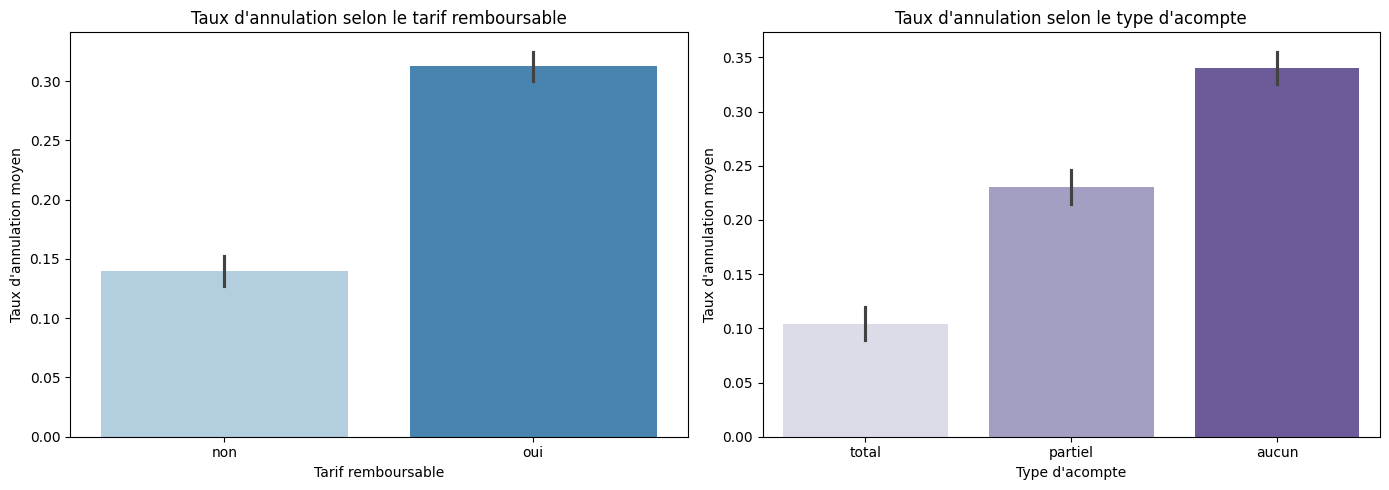

In [7]:
# 1. Chargement des données d'entraînement
train_df = pd.read_csv('reservations_train.csv')

# 2. Analyse croisée : Taux d'annulation selon le tarif remboursable
print("--- Taux d'annulation par tarif remboursable ---")
print(train_df.groupby('tarif_remboursable')['reservation_annulee'].mean() * 100)

# 3. Analyse croisée : Taux d'annulation selon le type d'acompte
print("\n--- Taux d'annulation par type d'acompte ---")
print(train_df.groupby('type_acompte')['reservation_annulee'].mean() * 100)

# 4. Génération de graphiques pour visualiser ces impacts
plt.figure(figsize=(14, 5))

# Graphique 1 : Tarif remboursable vs Annulation
plt.subplot(1, 2, 1)
sns.barplot(x='tarif_remboursable', y='reservation_annulee', data=train_df, palette='Blues')
plt.title("Taux d'annulation selon le tarif remboursable")
plt.ylabel("Taux d'annulation moyen")
plt.xlabel("Tarif remboursable")

# Graphique 2 : Type d'acompte vs Annulation
plt.subplot(1, 2, 2)
sns.barplot(x='type_acompte', y='reservation_annulee', data=train_df, palette='Purples')
plt.title("Taux d'annulation selon le type d'acompte")
plt.ylabel("Taux d'annulation moyen")
plt.xlabel("Type d'acompte")

plt.tight_layout()
plt.show()

In [10]:
# 1. Chargement
train_df = pd.read_csv('reservations_train.csv')

# 2. Préparation basique pour la baseline
# On sélectionne quelques features simples pour la baseline
features = ['delai_reservation_jours', 'prix_moyen_nuit_eur', 'adultes', 'enfants', 'nuits', 'tarif_remboursable']
X = train_df[features].copy()
y = train_df['reservation_annulee']

# 3. Création de la pipeline de la baseline (Baseline = Régression Logistique)
# On s'assure de traiter les valeurs manquantes et les variables catégorielles
num_features = ['delai_reservation_jours', 'prix_moyen_nuit_eur', 'adultes', 'enfants', 'nuits']
cat_features = ['tarif_remboursable']

preprocessor = ColumnTransformer(
    transformers=[
        ('num', SimpleImputer(strategy='median'), num_features),
        ('cat', OneHotEncoder(), cat_features)
    ])

baseline_model = Pipeline([
    ('preprocessor', preprocessor),
    ('scaler', StandardScaler(with_mean=False)), # with_mean=False est nécessaire pour Sparse Matrix si OneHotEncoder produit une telle matrice
    ('classifier', LogisticRegression(random_state=42))
])

# 4. Split train/test (même si TimeSeriesSplit sera utilisé à l'étape 3, pour la baseline on peut faire un split simple)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 5. Entraînement et évaluation
baseline_model.fit(X_train, y_train)
y_pred = baseline_model.predict(X_test)

print("--- Étape 2 : Modèle Baseline (Régression Logistique) ---")
print("Précision (Accuracy) :", accuracy_score(y_test, y_pred))
print("\nRapport de classification :\n", classification_report(y_test, y_pred))

--- Étape 2 : Modèle Baseline (Régression Logistique) ---
Précision (Accuracy) : 0.74375

Rapport de classification :
               precision    recall  f1-score   support

           0       0.74      1.00      0.85      1185
           1       0.69      0.02      0.04       415

    accuracy                           0.74      1600
   macro avg       0.72      0.51      0.45      1600
weighted avg       0.73      0.74      0.64      1600



In [16]:
# 1. Chargement et tri chronologique impératif (Exigence du sujet ISPM)
train_df = pd.read_csv('reservations_train.csv')
train_df = train_df.sort_values('date_reservation').reset_index(drop=True)

# 2. ÉTAPE 4 : Feature Engineering (Création de nouvelles variables utiles)
def add_features(df):
    df = df.copy()
    df['duree_totale_sejour'] = df['nuits']
    df['total_personnes'] = df['adultes'] + df['enfants'].fillna(0)
    df['is_direct'] = df['agent_id'].isna().astype(int)
    df['prix_par_personne'] = df['montant_total_eur'] / (df['total_personnes'] * df['nuits'].replace(0, 1))
    return df

train_df = add_features(train_df)

# Séparation Features / Cible
X = train_df.drop(columns=['reservation_id', 'reservation_annulee', 'date_reservation', 'date_arrivee', 'agent_id'])
y = train_df['reservation_annulee']

# Identification des types de colonnes
num_cols = X.select_dtypes(include=['int64', 'float64']).columns.tolist()
cat_cols = X.select_dtypes(include=['object', 'bool']).columns.tolist()

# Pipeline de prétraitement automatique
preprocessor = ColumnTransformer(
    transformers=[
        ('num', Pipeline([('imputer', SimpleImputer(strategy='median')), ('scaler', StandardScaler())]), num_cols),
        ('cat', Pipeline([('imputer', SimpleImputer(strategy='constant', fill_value='missing')),
                          ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False))]), cat_cols)
    ]
)

# 3. ÉTAPE 3 : Validation Temporelle (TimeSeriesSplit)
tscv = TimeSeriesSplit(n_splits=3)

print("--- ÉTAPE 3 & 4 : Validation Temporelle et Modèle avec Feature Engineering ---")
for fold, (train_index, val_index) in enumerate(tscv.split(X)):
    X_train_f, X_val_f = X.iloc[train_index], X.iloc[val_index]
    y_train_f, y_val_f = y.iloc[train_index], y.iloc[val_index]

    # Modèle : Random Forest avec les nouvelles features
    model = Pipeline([
        ('preprocessor', preprocessor),
        ('classifier', RandomForestClassifier(n_estimators=100, random_state=42))
    ])

    model.fit(X_train_f, y_train_f)
    preds = model.predict(X_val_f)
    score = f1_score(y_val_f, preds, pos_label=1)
    print(f"Fold {fold+1} - F1-score sur la classe annulation (1) : {score:.4f}")

--- ÉTAPE 3 & 4 : Validation Temporelle et Modèle avec Feature Engineering ---
Fold 1 - F1-score sur la classe annulation (1) : 0.0993
Fold 2 - F1-score sur la classe annulation (1) : 0.0746
Fold 3 - F1-score sur la classe annulation (1) : 0.0967


In [25]:
# 1. Re-entrainement sur TOUT le train set pour la soumission finale
train_df = pd.read_csv('reservations_train.csv')
test_df = pd.read_csv('reservations_test.csv')

# Application du même Feature Engineering (Etape 4)
def add_features(df):
    df = df.copy()
    df['duree_totale_sejour'] = df['nuits']
    df['total_personnes'] = df['adultes'] + df['enfants'].fillna(0)
    df['is_direct'] = df['agent_id'].isna().astype(int)
    # Protection contre division par zéro
    df['prix_par_personne'] = df['montant_total_eur'] / (df['total_personnes'] * df['nuits'].replace(0, 1))
    return df

train_df = add_features(train_df)
test_df = add_features(test_df)

X = train_df.drop(columns=['reservation_id', 'reservation_annulee', 'date_reservation', 'date_arrivee', 'agent_id'])
y = train_df['reservation_annulee']
X_test = test_df.drop(columns=['reservation_id', 'date_reservation', 'date_arrivee', 'agent_id'])

# Pipeline de pre-traitement
num_cols = X.select_dtypes(include=['int64', 'float64']).columns.tolist()
cat_cols = X.select_dtypes(include=['object', 'bool']).columns.tolist()

preprocessor = ColumnTransformer(
    transformers=[
        ('num', Pipeline([('imputer', SimpleImputer(strategy='median')), ('scaler', StandardScaler())]), num_cols),
        ('cat', Pipeline([('imputer', SimpleImputer(strategy='constant', fill_value='missing')),
                          ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False))]), cat_cols)
    ]
)

# Etape 5 : Analyse des erreurs (on fait une split 80/20 pour voir la matrice de confusion)
X_train_sub, X_val_sub, y_train_sub, y_val_sub = train_test_split(X, y, test_size=0.2, random_state=42, shuffle=False)
model = Pipeline([('preprocessor', preprocessor), ('classifier', RandomForestClassifier(n_estimators=100, random_state=42))])
model.fit(X_train_sub, y_train_sub)
preds_val = model.predict(X_val_sub)

print("--- ÉTAPE 5 : Analyse des erreurs (Matrice de Confusion) ---")
print(confusion_matrix(y_val_sub, preds_val))
print(classification_report(y_val_sub, preds_val))

# Etape 6 : Soumission finale
model.fit(X, y)
predictions = model.predict(X_test)
probabilities = model.predict_proba(X_test)[:, 1]

submission = pd.DataFrame({
    "reservation_id": test_df["reservation_id"],
    "probabilite_annulation": probabilities,
    "reservation_annulee": predictions
})

submission.to_csv("submission.csv", index=False)
print("\n--- ÉTAPE 6 : Fichier 'submission.csv' généré avec succès ! ---")

--- ÉTAPE 5 : Analyse des erreurs (Matrice de Confusion) ---
[[1130   39]
 [ 408   23]]
              precision    recall  f1-score   support

           0       0.73      0.97      0.83      1169
           1       0.37      0.05      0.09       431

    accuracy                           0.72      1600
   macro avg       0.55      0.51      0.46      1600
weighted avg       0.64      0.72      0.64      1600


--- ÉTAPE 6 : Fichier 'submission.csv' généré avec succès ! ---
